# Coursework Set week 4

**Common remarks**:

* Deadline: Sunday at 23:59h for the week of this task
* <font color='red'>Keep all the information in this template unaltered!</font>

**Please fill in the following fields:**

* Name: Anna van der Vecht
* Username: amvecht
* Student number: S6390382
* Group (AS1, etc.): AS5

-----

In [1]:
totalpoints = currentpoints = 0

### Monte Carlo Error Propagation (4 pt) <font color='red'><b>COURSEWORK</b></font>

One of the classical Physic Lab experiment is to use pendulum to calculate the local gravitational acceleration, ``g``, from the measurements of the pendulum length ``L`` and the oscillation period ``T``.

The formula is expressed as follows:

$$ g=\frac{4\pi^2 L}{T^2} $$

You have got a set of measurements of $L=1.00\pm0.01\ \mathrm{(m)}$ and $T=2.01\pm0.02\ \mathrm{(s)}$.

* Like in Physics Lab, use Tyler expansion described above to propagate the error. Write your derivation in Markdown.

* Calculate the error of the derived ``g``.

* Apply Monte Carlo error propagation to estimate the value and uncertainty of ``g``.

* Make appropriate comments.

* Compare the two results.

In [2]:
# Correction: Made the markdown derivation go untill the final equations for g and the error
import numpy as np # Import library numpy with alias np
import math

"""
Calculation of g using formulas from question:
"""
L = 1.00 # Give the value for the pendulum length (m)
err_L = 0.01 # Give the value for the error in length (m)

T = 2.01 # Give the value for the oscillation period (s)
err_T = 0.02 # Give the value for the error in the perio (s)

g_calc = (4 * np.pi**2 * L) / (T**2) # Calculate gravitational acceleration

We want to calculate the uncertainty of the gravitational acceleration:

$$
g = \frac{4\pi^2 L}{T^2}
$$

The first-order Taylor expansion gives the propagated uncertainty:

$$
\sigma_f^2 =
\left(\frac{\partial f}{\partial x}\sigma_x\right)^2 +
\left(\frac{\partial f}{\partial y}\sigma_y\right)^2
$$

where \(\sigma_x\) and \(\sigma_y\) are the uncertainties of the input variables.

For the partial derivatives we get:

$$
\frac{\partial g}{\partial L} = \frac{\partial}{\partial L} \left(\frac{4\pi^2L}{T^2} \right) = \frac{4\pi^2}{T^2}
$$

and

$$
\frac{\partial g}{\partial T} = \frac{\partial}{\partial T} \left( \frac{4\pi^2 L}{T^2} \right) 
= - 8 \pi^2 L * T^{-3} = - \frac{8 \pi^2 L}{T^3}
$$

so g and the error of g can be calculated using the following:

$$
g = \frac{4\pi^2 L}{T^2}
$$

$$
\sigma_g = \sqrt{ \left(\frac{\partial g}{\partial L}\sigma_L\right)^2+\left(\frac{\partial g}{\partial T}\sigma_T\right)^2}
$$


In [3]:
"""
Calculation of error of g using above mentioned formula rewritten as:
error = sqrt( (derivative_a*error_a)^2 + (derivative_b*error_b)^2 + etc.)
"""
deriv_L = 4 * np.pi**2 / T**2 # As calculated above
deriv_T = -8 * np.pi**2 * L / T**3 # As calculated above

err_g_calc = np.sqrt( (deriv_L * err_L)**2 + (deriv_T * err_T)**2 ) # Calculate error of g using above mentioned formula

# Print g (:.5g prints with maximum of 5 significant digits)
print(f"Calculated g = {g_calc:.5g} ± {err_g_calc:.5g} m/s^2\n") #also start new line after this in printing

"""
Apply Monte Carlo to estimate value and uncertainty of g
"""

N = 100000 # Set amount

# randomly sample L and T from a normal/gaussian distribution with N data points
L_sample = np.random.normal(L, err_L, N) 
T_sample = np.random.normal(T, err_T, N)

# Calculate g for each value set in numpy arrays from above
g_mc_array = 4 * np.pi**2 * L_sample / T_sample**2

#calculate average and standard deviation to get value for g and its error:
g_mc = np.mean(g_mc_array) # Calculate average aka mean
err_g_mc = np.std(g_mc_array) # Calculate error aka standard deviation

# Print Monte Carlo calculated g (:.5g prints with maximum of 5 significant digits)
print(f"Monte carlo g = {g_mc:.5g} ± {err_g_mc:.5g} m/s^2\n") #also start new line after this in printing

"""
Compare regularly calculated result with Monte Carlo result for g.
Done using isclose(value1, value2, amount of decimals)
If the output is true it will print how equal the two values are
"""
print("Comparison:")
if math.isclose(g_calc, g_mc, abs_tol=0.001):
    print(f"g_calculated = {g_calc:.5g} ± {err_g_calc:.5g} and g_Monte_Carlo = {g_mc:.5g} ± {err_g_mc:.5g} \nare the equal up until 3 decimals in their value")
elif math.isclose(g_calc, g_mc, abs_tol=0.01):
    print(f"g_calculated = {g_calc:.5g} ± {err_g_calc:.5g} and g_Monte_Carlo = {g_mc:.5g} ± {err_g_mc:.5g} \nare the equal up until 2 decimals in their value")
elif math.isclose(g_calc, g_mc, abs_tol=0.1):
    print(f"g_calculated = {g_calc:.5g} ± {err_g_calc:.5g} and g_Monte_Carlo = {g_mc:.5g} ± {err_g_mc:.5g} \nare the equal up until 1 decimal in their value")

Calculated g = 9.7716 ± 0.21763 m/s^2

Monte carlo g = 9.7741 ± 0.21816 m/s^2

Comparison:
g_calculated = 9.7716 ± 0.21763 and g_Monte_Carlo = 9.7741 ± 0.21816 
are the equal up until 2 decimals in their value


In [4]:
# Leave unaltered
totalpoints += 4
currentpoints += 0.0

### Complex roots of a quadratic equation (4 pt) <font color='red'><b>COURSEWORK</b></font>
  
Use the information in the notebook about complex numbers to write a program that can calculate the (complex) roots of a quadratic equation with the quadratic formula:

$$ y=ax^2+bx+c $$

The requirement of this program is as follows:

* User can supply constants ``a``, ``b`` and ``c`` with Python function `input()`.
* The program can deal with complex roots.
* Your program must print the equation with its constants and its roots.
* The solutions must be inserted to the original equation to prove that $f(x)=0$.

**Answer**:

In [5]:
import cmath # import cmath for complex solutions and square roots
import math  # import math for real solutions and square roots

# Give input:
print(f"Give coefficients for the quadratic equation: ax^2 + bx + c = 0")

a = float(input("Enter coefficient a: "))
b = float(input("Enter coefficient b: "))
c = float(input("Enter coefficient c: "))

#print the equation including given variables
print(f"\nThe quadratic equation is: f(x)={a}x^2 + {b}x + {c}") 

# Calculate discriminant using input a, b, and c:
D = (b**2) - 4 * a * c 

# If D is larger than 0 provide the two answers by calculating x using the formula from the question
if D > 0:
    x_1 = ( -b + math.sqrt( (b**2) - 4 * a * c) ) / (2 * a)
    x_2 = ( -b - math.sqrt( (b**2) - 4 * a * c) ) / (2 * a)
    print(f"f(x) gives 2 solutions.")
    print(f"\nThe solutions are x={x_1:.5g}, and x={x_2:.5g}")  
    print(f"\nVerify solutions by substituting back in f(x):")
    f1 = a * (x_1**2) + b * x_1 + c
    f2 = a * (x_2**2) + b * x_2 + c
    print(f"f({x_1:.5g}) = {a}*({x_1:.5g})² + {b}*({x_1:.5g}) + {c} = {f1:.5g}")
    print(f"f({x_2:.5g}) = {a}*({x_2:.5g})² + {b}*({x_2:.5g}) + {c} = {f2:.5g}")

# If D is 0 provide the answer by calculating x (- or + square root will give the same answer since you add or substract 0 so we only use 1 of them to calculate x)
elif D == 0:
    x = ( -b + math.sqrt( (b**2) - 4 * a * c) ) / (2 * a)
    print(f"There is only 1 solution for f(x), with values a={a}, b={b}, c={c}") 
    print(f"\nThe solution is x={x:.5g}")
    print(f"\nVerify solution by substituting back in f(x):")
    f = a * (x**2) + b * x + c
    print(f"f({x:.5g}) = {a}*({x:.5g})² + {b}*({x:.5g}) + {c} = {f:.5g}")

# Calculate complex solutions when D < 0:
elif D < 0:
    x_1_c = ( -b + cmath.sqrt( (b**2) - 4 * a * c) ) / (2 * a)
    x_2_c = ( -b - cmath.sqrt( (b**2) - 4 * a * c) ) / (2 * a)
    print(f"f(x) gives 2 complex solutions.")
    print(f"\nThe solutions are x={x_1_c:.5g}, and x={x_2_c:.5g}")
    print(f"\nVerify solutions by substituting back in f(x):")
    f1 = a * (x_1_c**2) + b * x_1_c + c
    f2 = a * (x_2_c**2) + b * x_2_c + c
    print(f"f({x_1_c:.5g}) = {a}*({x_1_c:.5g})² + {b}*({x_1_c:.5g}) + {c} = {f1:.5g}")
    print(f"f({x_2_c:.5g}) = {a}*({x_2_c:.5g})² + {b}*({x_2_c:.5g}) + {c} = {f2:.5g}")


"""Note: I added :.5g to all printing of the x solutions. This code makes it so that there is a maximum of 5 significant digits printed. It still calculates everything with all decimals so it does not affect any results other than making it more overseeable. I also added \n to a few lines in order to make the final printed result more clear"""

Give coefficients for the quadratic equation: ax^2 + bx + c = 0


Enter coefficient a:  2
Enter coefficient b:  1
Enter coefficient c:  3



The quadratic equation is: f(x)=2.0x^2 + 1.0x + 3.0
f(x) gives 2 complex solutions.

The solutions are x=-0.25+1.199j, and x=-0.25-1.199j

Verify solutions by substituting back in f(x):
f(-0.25+1.199j) = 2.0*(-0.25+1.199j)² + 1.0*(-0.25+1.199j) + 3.0 = 4.4409e-16+0j
f(-0.25-1.199j) = 2.0*(-0.25-1.199j)² + 1.0*(-0.25-1.199j) + 3.0 = 4.4409e-16+0j


'Note: I added :.5g to all printing of the x solutions. This code makes it so that there is a maximum of 5 significant digits printed. It still calculates everything with all decimals so it does not affect any results other than making it more overseeable. I also added \n to a few lines in order to make the final printed result more clear'

In [6]:
# Leave unaltered
totalpoints += 4
currentpoints += 0.0

### Area under a Gaussian (6 pt) <font color='red'><b>COURSEWORK</b></font>

A one dimensional Gaussian function is given by:

$$f(x) = A\ e^{\frac{-{(x-x_0)}^2}{2 \sigma^2}} + z_0$$

$A$ is the amplitude, $x_0$ is the position of the peak, $\sigma$ is the width of the peak
and $z_0$ is the offset in $y$.  

This function can be written in Python as follows:

```python
def gauss(x, A, x0, sigma, z0):
    return A*np.exp(-(x-x0)**2/(2*sigma**2))+z0
```

1. Set in the calling environment:
```python
    A = 1.0
    x0 = 0.0
    sig = 2.0
    z0 = 0.0
```
2. Plot this function between -10 and 10 with 200 samples.
3. Use function `scipy.integrate.quad()` to find the area between ``x=0`` and ``x=2.5``.
4. Use function `matplotlib.pyplot.fill_between()` to mark that area in your plot.
5. Calculate the area between $-\infty$ and $\infty$ ($\approx 5.01$).
6. Given is the integral for the total area under the curve:

    $$\int _{-\infty }^{\infty }Ae^{-(x-x_0)^{2}/(2\sigma^{2})}\,\mathrm{d}x=A \sigma \cdot {\sqrt {2\pi }}$$

   Calculate this area for the values of the parameters given above and prove with ``quad()`` that the two are the same.

7. Make the last part an executable script, called ``gaussarea``. The user can enter values for ``A``, ``x0``, ``sig`` and ``z0`` and the integration limits. The programme then calculates the area under the curve between the integration limits using function ``quad()``. The programme must includes a plot of the curve, the integration area, and the value of that area in a legend.
8. Insert the generated plot in a separate markdown cell below your code cell, and upload your script to GitHub. Provide your GitHub website link in the notebook too for TA to check. 
   
**Answers**:   

The area between 0 and 2.5 is equal to: 1.977
The area between -inf and inf, calculated with quad, is equal to: 5.01
The area between -inf and inf, calculated with given formula, is equal to: 5.01
The values are equal


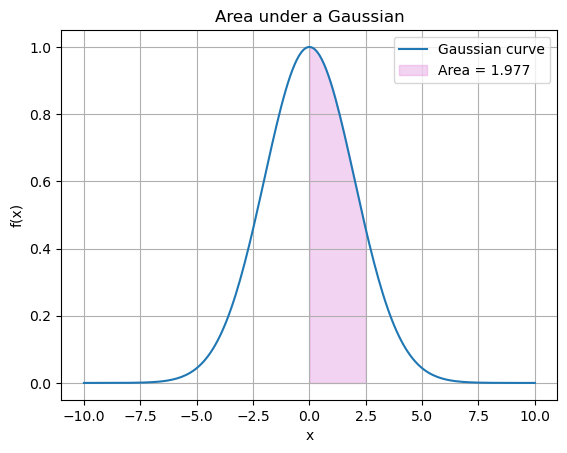

In [7]:
# Import libraries with alias's
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad

# Define given function and set in the calling environment
def gauss(x, A, x0, sigma, z0):
    return A*np.exp(-(x-x0)**2/(2*sigma**2))+z0
A = 1.0 # Amplitude
x0 = 0.0 # Peak position
sig = 2.0 # Peak width
z0 = 0.0 # offset in y

# Plot function
x = np.linspace(-10, 10, 200) # Generate 200 samples between -10 and 10 for x
y = gauss(x, A, x0, sig, z0) # Use defined function with calling environment values for y
plt.figure()
plt.plot(x, y, label = 'Gaussian curve') # Plot x against y and label the plot

"""
Integrate to find area between 0 and 2.5
Use quad to calculate integral. lambda t makes it so that t is the variable we integrate over.
I change the variable to avoid confusion in plotting.
"""
area, error = quad(lambda t: gauss(t, A, x0, sig, z0), 0, 2.5) # quad calculates value and uncertainty, so we assign area to value and error to the uncertainty
print(f"The area between 0 and 2.5 is equal to: {area:.5g}") # prints area with maximum of 5 significant digits

# Fill area between 0 and 2.5 under gaussian curve
x_fill = np.linspace(0, 2.5, 100)
y_fill = gauss(x_fill, A, x0, sig, z0)
plt.fill_between(x_fill, y_fill, color='orchid', alpha=0.3, label=f"Area = {area:.4g}")

# Calculate area between -inf and +inf (same way as between 0 and 2)
area_inf, error_inf = quad(lambda t: gauss(t, A, x0, sig, z0), -np.inf, np.inf) # np.inf sets bounds as infinite
print(f"The area between -inf and inf, calculated with quad, is equal to: {area_inf:.3g}") # prints area with maximum of 3 significant digits (like given in question)

# Calculate area between -inf and +inf (using formula)
area_int = A * sig * np.sqrt(2 * np.pi)
print(f"The area between -inf and inf, calculated with given formula, is equal to: {area_int:.3g}") # same as above


if math.isclose(area_inf, area_int, abs_tol=0.01): # Check if they are equal up untill 2 decimals
    print("The values are equal")
else:
    print("The values are not equal")

# Graph customisation:
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Area under a Gaussian")
plt.legend()
plt.grid(True)
plt.show()

Link to github: https://github.com/amvdvecht/PROGNUM-repo.git

(script is under \TASK4\Notebooks_python\ as gaussarea)

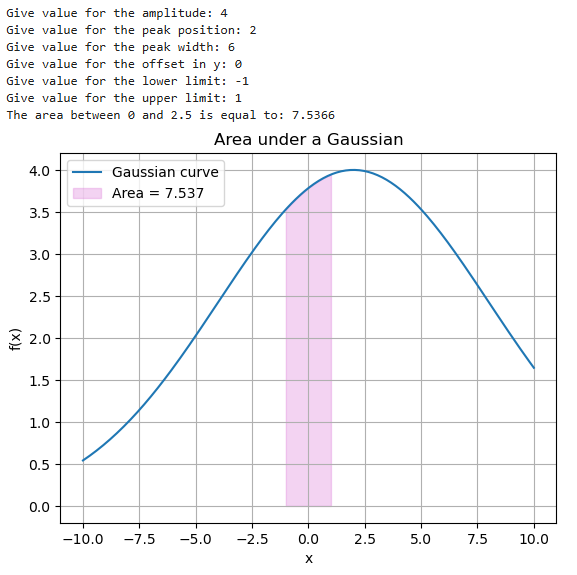

In [8]:
# Leave unaltered
totalpoints += 6
currentpoints += 0.0

### Calculate integral of a user supplied function (6 pt) <font color='red'><b>COURSEWORK</b></font>

Write a programme that calculates the integral of any function from the user input using ``eval()``, which is a string representing a function and a variable (floating number) for which the function will be evaluated.

* Call from ``numpy import sin, cos, exp, pi`` to apply these functions and constants in your code.
* Use ``scipy.integrate.quad()`` to calculate the integral of the formula below between $x=0$ and $x=\pi$
* Use Monte Carlo Integration to calculate the integral of the formula below for $x=0$ and $x=\pi$

$$ f(x)=x^4+e^{\sin{x}+\cos{x}} $$

Make the function robust with try/except clauses. Demonstrate exceptions for wrong expressions and unknown functions in an expression (NameError) etc. Print messages that tell a user what they have done wrong!

Make the above code an executable script called ``interate_user_function``, and upload to GitHub.

* Create a separate cell, and use SymPy expression to calculate the integral of the formula below for $x=0$ and $x=\pi$.

In [9]:
# Correction: added link to github and added the evaluated integrals value to the printed simpy expression

#import libraries as alias
import numpy as np
from scipy.integrate import quad
from numpy import sin, cos, exp, pi  # functions/constants user can use

#Define function montecarlo
def montecarlo(f, a, b, N=100000):
    """
    Compute integral between, user provided a and b and function f, using the monte carlo method.
    """
    try:
        x = np.random.uniform(a, b, N) # N amount of uniform distributed numbers between a and b 
        y = y = np.array([eval(f, {"x": xi, "sin": sin, "cos": cos, "exp": exp, "pi": pi}) for xi in x]) # Evaluate function f for each item in array x (add definitions so there is less risk of errors)
        integral = (b - a) * np.mean(y) # Calculate integral
        return integral
    except NameError as e:
        print(f"NameError: {e}. Did you use a function or variable not defined?")
        return None
    except Exception as e:
        print(f"Error during Monte Carlo integration: {e}")
        return None

# Ask user input
fstr = input("Enter a function f(x):")

# Calculate integral with quad
# Try/except clauses for input function
try:
    f = lambda x: eval(fstr, {"x": x, "sin": sin, "cos": cos, "exp": exp, "pi": pi}) # Redefine f as eval(f) with variable x (define ther functions and variables for less risk of error)
    result, error= quad(f, 0, np.pi) #Calculate integral using quad between 0 and pi (as asked in question)
    print(f"Integration with quad gives result: {result}")
except Exception as e:
    print(f"Error: {e}") # Print reason why it wont work

# Calculate integral with monte carlo (previously defined function)
result_mc = montecarlo(fstr,0,np.pi) #Calculate integral between 0 and pi (as asked in question)
if result_mc is not None: #add another failsafe
    print(f"Integral with Monte carlo gives result: {result_mc}")

Enter a function f(x): x


Integration with quad gives result: 4.934802200544679
Integral with Monte carlo gives result: 4.931325068395862


Script can be found under \TASK4\Notebooks_python\

In [15]:
# Import SymPy with alias sp
import sympy as sp

# Define the symbol x (variable in function)
x = sp.symbols('x')

# Ask user for input function f with variable x
fstr = input("Enter a function f(x): ") # sin(x) + x**2 in the case of the example asked for

# Convert to SymPy
f = sp.sympify(fstr)

# Calculate integral of function f with variable x ranging from 0 to pi
integral = sp.integrate(f, (x, 0, sp.pi))
intvalue = integral.evalf()

# Print calculated result
print(f"The integral of {f} from x=0 to x=π is: {integral}, which results in a value of: {intvalue}")


""" Output for asked function: Enter a function f(x):  sin(x) + x**2 The integral of x**2 + sin(x) from x=0 to x=π is: 2 + pi**3/3 """

Enter a function f(x):  x


The integral of x from x=0 to x=π is: pi**2/2, which results in a value of: 4.93480220054468


' Output for asked function: Enter a function f(x):  sin(x) + x**2 The integral of x**2 + sin(x) from x=0 to x=π is: 2 + pi**3/3 '

Link to github repository: https://github.com/amvdvecht/PROGNUM-repo.git (The link to my github repository was also already given in the previous question, and the path to the script is in the above markdown cell)

In [11]:
# Leave unaltered
totalpoints += 6
currentpoints += 0.0

### Plotting Hertzsprung–Russell (HR) diagram (6 pt) <font color='red'><b>COURSEWORK</b></font>

``Hertzsprung-Russell (HR) diagram``, which indicates the stellar evolution, is an important astrophysical plot graphing stellar luminosity (brightness, absolute magnitude) against surface temperature (or colour). This diagram clearly states the evolutionary pathways of stars and where they are in their lifetime. With this, we classify several important stages of a star's life -- main sequence stars, giants, or white dwarfs. 

In this exercise, a combined APOGEE/Gaia star catalog has been prepared for you to create an HR diagram -- download the catalogue from the BrightSpace: ``APOGEE+Gaia_stars.fits``

* To read FITS file, you need AstroPy, which is a library that is widely used in Astronomy.

```python
from astropy.io import fits

# Open the FITS file
hdul = fits.open('APOGEE_stars.fits')

# Access the primary data (in this case, it is a Table)
data = hdul[1].data  # Often, the first extension contains the table
colnames = hdul[1].columns.names # List of the column names
```

* "data" is a AstroPy data class, but it can be used like a ndarray as follows.

```python
print(data[0]) # The first row of the catalogue
print(data['STARFLAG']) # List all rows in the column of "STARFLAG"
print(data['STARFLAG'][:10]) # Print the first 10 elements in the column of "STARFLAG"
print(data['STARFLAG'][-10:]) # Print the last 10 elements in the column of "STARFLAG"
```

* Firstly, let's select data with good quality and robust measurements using the following criteria:
    * STARFLAG == 0
    * ASPCAPFLAG == 0
    * SNR > 10
    * GAIAEDR3_PARALLAX/ GAIAEDR3_PARALLAX_ERROR > 5
    * GAIAEDR3_PHOT_G_MEAN_MAG is not NaN value
    * GAIAEDR3_PHOT_BP_MEAN_MAG is not NaN value
    * GAIAEDR3_PHOT_RP_MEAN_MAG is not NaN value

* From the selected data, let's randomly choose about **80% of the data** for plotting the HR diagram. 

* The HR diagram contains
    * $x$-axis: colour -- BP-RP
    * $y$-axis: absolute magnitude -- $M_G$


**<span style="color:red">Warning</span>**: note that from observation, we only have apparent magnitude (i.e. observed magnitude). To convert into absolute magnitude requires **Distance Modulus**: 

$$ M_G = m_G + 5\log10{(\mathrm{parallax}/1000)} + 5 $$

* Apply a rough binary classification scheme to separate giant branch and main sequence (MS) stars.
    * Giant branch: $ M_G<3.5 $ and $(BP-RP)>0.8$
    * MS: assume the rest of the data is MS

* It seems that we do not have sufficient samples in the White Dwarf (WD) region. Use the following criteria to draw vertical and horizontal lines, as well as define a box indicating the location of WD on the HR diagram.
    * $(BP-RP)\leq0.8$ and $ M_G>10 $ (very faint)
 
* Make a scatter plot and customise it to be look like the plot shown here.

<img src="attachment:14037eb3-1593-4349-8d4a-ae0bd96b6e97.png" alt="HR Diagram" width="600">

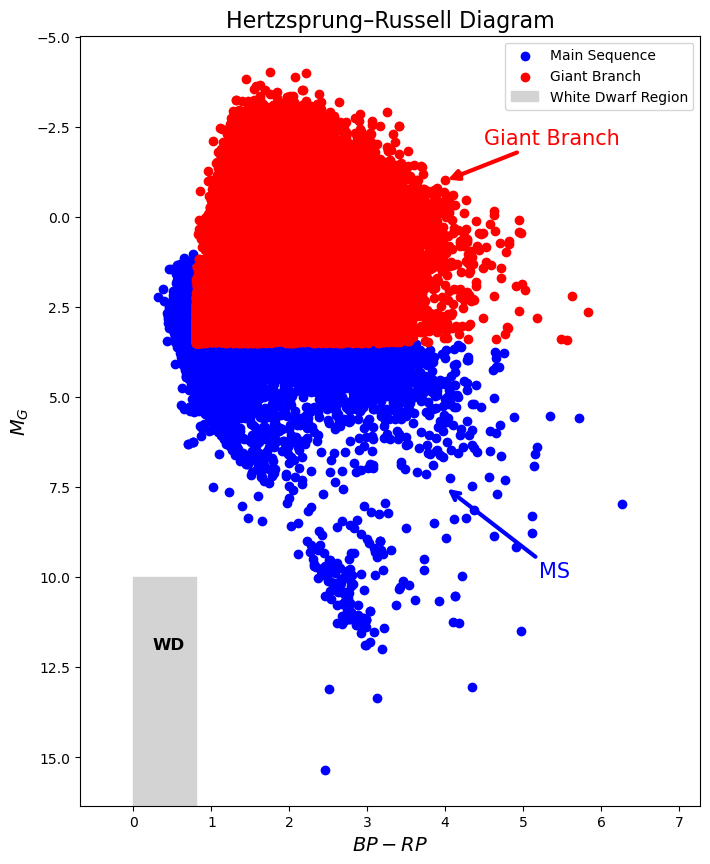

In [12]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits

# Open the FITS file and extract the table of stars.
hdul = fits.open('APOGEE_stars.fits')  
data = hdul[1].data # first extension contains data we need
colnames = hdul[1].columns.names # List all column names for future reference


# Make a mask with all given criteria to later use on the data
mask = (
    (data['STARFLAG'] == 0) &
    (data['ASPCAPFLAG'] == 0) &
    (data['SNR'] > 10) &
    (data['GAIAEDR3_PARALLAX'] / data['GAIAEDR3_PARALLAX_ERROR'] > 5) &
    (~np.isnan(data['GAIAEDR3_PHOT_G_MEAN_MAG'])) &
    (~np.isnan(data['GAIAEDR3_PHOT_BP_MEAN_MAG'])) &
    (~np.isnan(data['GAIAEDR3_PHOT_RP_MEAN_MAG']))
)
good_data = data[mask] # apply mask to data

# Randomly select 80% of the data for further calculations
np.random.seed(1) # Seed provides same set of values each time there is a reset
sample_indices = np.random.choice(len(good_data), size=int(0.8*len(good_data)), replace=False) #take 80% of data
sample_data = good_data[sample_indices] # Take the 80% of data from good_data

# define all needed data from the sample data
parallax = sample_data['GAIAEDR3_PARALLAX'] # Gaia parallax in milliarcseconds
m_G = sample_data['GAIAEDR3_PHOT_G_MEAN_MAG'] # Apparent G-band magnitude
BP = sample_data['GAIAEDR3_PHOT_BP_MEAN_MAG'] # BP magnitude
RP = sample_data['GAIAEDR3_PHOT_RP_MEAN_MAG'] # RP magnitude

# Calculate the distance, Absolute magnitude in green and colour index BP-RP
distance_pc = 1000.0 / parallax # Convert parallax to distance in parsecs
M_G = m_G + 5 - 5*np.log10(distance_pc)  # Calculate absolute magnitude
colour = BP - RP # Calculate colour index BP-RP

# Make masks for all provided conditions
giant_mask = (M_G < 3.5) & (colour > 0.8) # Giant branch mask with absolute magnitude in green below 3.5 and BP-RP bigger than 0.8
wd_mask = (M_G > 10) & (colour <= 0.8)    # White dwarf mask with absolute magnitude in green bigger than 10 and colour smaller or equal to 0.8
ms_mask = ~(giant_mask | wd_mask)        # Main sequence mask with everything that is not in wd or giang branch

# Plot
plt.figure(figsize=(8,10)) # Set figure size

# Plot the HR diagram using a scatter plot
# x-axis: BP-RP colour and y-axis: Absolute magnitude in G-band
plt.scatter(colour[ms_mask], M_G[ms_mask], color='blue', label='Main Sequence') # Plot MS stars
plt.scatter(colour[giant_mask], M_G[giant_mask], color='red', label='Giant Branch') # Plot giants

# Make filled box for white dwarfs with bounds given in question
plt.fill_betweenx([10, 20], 0, 0.8, color='lightgrey', label = 'White Dwarf Region') # Grey rectangle for WD region
plt.text(0.25, 12, 'WD', fontsize=12, fontweight='bold')    # Label the box

plt.gca().invert_yaxis() # Invert y-axis so brighter stars appear at the top

"""
Add annotations to label different stellar populations.
Arrows and text improve readability of the HR diagram.
"""
plt.annotate('Giant Branch', xy=(4, -1), xytext=(4.5, -2),
             color='red', fontsize=15,
             arrowprops=dict(arrowstyle='->', color='red', lw=3))

plt.annotate('MS', xy=(4, 7.5), xytext=(5.2,10),
             color='blue', fontsize=15,
             arrowprops=dict(arrowstyle='->', color='blue', lw=3))


"""
Add labels, title, legend, and grid for clarity.
- xlabel: BP-RP color
- ylabel: Absolute magnitude M_G
- title: HR diagram
- legend: Stellar categories
- grid: subtle reference lines
"""
plt.xlabel(r'$BP - RP$', fontsize=14)
plt.xlim((min(colour)-1), (max(colour)+1))  # Set x-axis range from one below minimum to one above maximum
plt.ylim((max(M_G)+1),(min(M_G)-1)) # set y-axis same as x but flipped and for 
plt.ylabel(r'$M_G$', fontsize=14)
plt.title('Hertzsprung–Russell Diagram', fontsize=16)
plt.legend(loc='upper right')


plt.show() # Display the HR diagram

In [13]:
# Leave unaltered
totalpoints += 6
currentpoints += 0.0

## Finishing up

**Please read the section about your report in the task documentation very carefully before submitting it to BrightSpace.**

------------

## T.A. Grading


In [14]:
# Leave unaltered
taskgrade = round(10*currentpoints/totalpoints, 1) if totalpoints != 0 else 0
print(f"Total number of points: {totalpoints}. Student score: {currentpoints}.  Task Grade = {taskgrade}")

Total number of points: 26. Student score: 0.0.  Task Grade = 0.0
